# 二分查找

In [ ]:
nums = [5,7,7,8,8,10]
target = 8

index_left = 0
index_right = len(nums) -1
while index_left <= index_right:
    index_center = int((index_left + index_right)/2)
    if nums[index_center] >= target:
        index_right = index_center - 1
    else:
        index_left = index_center + 1

print(index_left)

- Exercises:
    - <span id='P.34'></span> [34. 在排序数组中查找元素的第一个和最后一个位置](https://leetcode.cn/problems/find-first-and-last-position-of-element-in-sorted-array/)
    - <span id='P.35'></span> [35. 搜索插入位置](https://leetcode.cn/problems/search-insert-position/)
    - <span id='P.704'></span> [704. 二分查找](https://leetcode.cn/problems/binary-search/)

<span id='P.56'></span>
# [56. 合并区间](https://leetcode.cn/problems/merge-intervals/)
以数组$intervals$表示若干个区间的集合，其中单个区间为$intervals[i] = [start_i, end_i]$。请你合并所有重叠的区间，并返回**一个不重叠的区间数组，该数组需恰好覆盖输入中的所有区间**。

In [ ]:
intervals = [[2,6],[1,3],[8,10],[15,18]]

intervals.sort()
output = [intervals[0]]
for ii in range(1,len(intervals)):
    if output[-1][1] < intervals[ii][0]:
        output.append(intervals[ii])
    else:
        output[-1][1] = max(output[-1][1],intervals[ii][1])

print(output)

In [ ]:
#include <vector>
#include <algorithm>
#include <iostream>

std::vector<std::vector<int>> intervals = {{1,3},{2,6},{8,10},{15,18}};

sort(intervals.begin(), intervals.end());
std::vector<std::vector<int>> output = {intervals[0]};
for (int ii = 1; ii < intervals.size(); ii++) {
    if (output.back()[1] < intervals[ii][0]) {
        output.emplace_back(intervals[ii]);
    }
    else {
        output.back()[1] = std::max(output.back()[1], intervals[ii][1]);
    }
}

for (auto interval : output) {
    std::cout << interval[0] << ", " << interval[1] << std::endl;
}

- Exercises:
    - <span id='P.57'></span> [57. 插入区间](https://leetcode.cn/problems/insert-interval/)

# 优化
## 上凸函数找最大值

In [ ]:
lb, rb, interval = -2, 3, 10

def f(x):
    return -(x - 1)**2 + 1

seq_x = [lb + (rb - lb) / interval * ii for ii in range(interval + 1)]
seq_y = [f(x) for x in seq_x]

import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(seq_x, seq_y, color="red", linestyle=':', marker='X', label='test')
ax.legend(loc='upper left')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 0))

In [ ]:
# 线搜法
delta = float("inf")
step = 0.5
x = lb
while delta >= 0.0001:
    temp = f(x + step) - f(x)
    if temp < 0:
        step *= 0.5
    else:
        delta = temp
        x = x + step
        print(x)

<span id='P.69'></span>
## [69. x 的平方根 ](https://leetcode.cn/problems/sqrtx/)
$\iff$ <span id='LCR.072'></span> [LCR 072. x 的平方根](https://leetcode.cn/problems/jJ0w9p/)<br>
给你一个非负整数`x`，计算并返回`x`的**算术平方根**。<br>
由于返回类型是整数，结果只保留**整数部分**，小数部分将被**舍去**。<br>
注意：不允许使用任何内置指数函数和算符，例如`pow(x, 0.5)`或者`x ** 0.5`。

In [ ]:
lb, rb, interval = -2., 3., 10
target = 3

def f(x):
    return x**2 - target

seq_x = [lb + (rb - lb) / interval * ii for ii in range(interval + 1)]
seq_y = [f(x) for x in seq_x]

import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(seq_x, seq_y, color="red", linestyle=':', marker='X', label='test')
ax.legend(loc='upper left')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 0))

### 牛顿迭代法
Let $f(x) = x^2 - \text{target}$, then 
$x_\text{new} = x - \frac{f(x)}{f^{'}(x)}$

In [ ]:
def f(x):
    return x**2 - target

def df(x):
    return 2 * x

x = rb
delta_x = float("inf")

while delta_x > 1e-4:
    x_new = x - f(x)/df(x)
    delta_x = abs(x_new - x)
    x = x_new
print(int(x))

题解2: 二分查找

In [ ]:
left, right = 0, target
ans = -1
while left <= right:
    center = int((left + right) / 2)
    if center**2 <= target:
        ans = center
        left = center + 1
    else:
        right = center - 1

print(ans)

## 单调函数找零值
### 牛顿迭代法

In [ ]:
lb, rb, interval = -2., 3., 10

def f(x):
    return x**3

seq_x = [lb + (rb - lb) / interval * ii for ii in range(interval + 1)]
seq_y = [f(x) for x in seq_x]

import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(seq_x, seq_y, color="red", linestyle=':', marker='X', label='test')
ax.legend(loc='upper left')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_position(('data', 0))

In [ ]:
def df(x):
    return 3 * x**2

x = rb
delta_x = float("inf")

while delta_x > 1e-4:
    x_new = x - f(x)/df(x)
    delta_x = abs(x_new - x)
    x = x_new
print(x)

### 二分法

In [ ]:
left = lb
right = rb
while left < right and right - left > 1e-4:
    center = (left + right) / 2
    val = f(center)
    if val > 0:
        right = center
    else:
        left = center
    print(left)

<span id='P.633'></span>
# [633. 平方数之和](https://leetcode.cn/problems/sum-of-square-numbers/)
给定一个非负整数$c$，你要判断是否存在两个整数$a$和$b$，使得$a^2 + b^2 = c$。

In [ ]:
import math
def judgeSquareSum(c):
    for a in range(int(math.sqrt(c)) + 1):
        b = math.sqrt(c - a * a)
        if b == int(b):
            return True
    return False
judgeSquareSum(5)

In [ ]:
#include <iostream>

bool judgeSquareSum(int c) {
    for (long a = 0; a * a <= c; a++) {
        double b = sqrt(c - a * a);
        if (b == int(b)) {
            return true;
        }
    }
    return false;
}
std::cout << judgeSquareSum(5) << std::endl;

<span id='P.343'></span>
## [343. 整数拆分](https://leetcode.cn/problems/integer-break/)
给定一个正整数`n`，将其拆分为`k`个**正整数**的和（`k >= 2`），并使这些整数的乘积最大化。<br>
返回*你可以获得的最大乘积*。

**示例 1**:
> **输入**: n = 2<br>
**输出**: 1<br>
**解释**: 2 = 1 + 1, 1 × 1 = 1。

**示例 2**:
> **输入**: n = 10<br>
**输出**: 36<br>
**解释**: 10 = 3 + 3 + 4, 3 × 3 × 4 = 36。

**提示**:
- `2 <= n <= 58`

> 题解: https://leetcode.cn/problems/integer-break/solutions/29098/343-zheng-shu-chai-fen-tan-xin-by-jyd/<br>
>1. 当 $n \leq 3$ 时，按照规则应不拆分，但由于题目要求必须拆分，因此必须拆出一个因子 $1$ ，即返回 $n - 1$ 。
2. 当 $n>3$ 时，求 $n$ 除以 $3$ 的 整数部分 $a$ 和 余数部分 $b$ （即 $n = 3a + b$ ），并分为以下三种情况：
    - 当 $b = 0$ 时，直接返回 $3^a$；
    - 当 $b = 1$ 时，要将一个 $1 + 3$ 转换为 $2+2$，因此返回 $3^{a-1} \times 4$；
    - 当 $b = 2$ 时，返回 $3^a \times 2$。

In [ ]:
int integerBreak(int n) {
    if (n > 3) {
        if (n % 3 == 0) {
            return int(pow(3, n / 3));
        } else if (n % 3 == 1) {
            return int(pow(3, n / 3 - 1)) * 4;
        } else {
            return int(pow(3, n / 3)) * 2;
        }
    } else {
        return n - 1;
    } 
}

# 进制
https://www.cnblogs.com/wuchanming/p/4448660.html

In [ ]:
#include <iostream>
#include <string>
using namespace std;

string val = "19.25";

int pos = val.find('.', 0);
std::cout << pos << std::endl;

int intpart = stoi(val.substr(0, pos));
double decpart = stof(val.substr(pos, val.length() - pos));

std::cout << "intpart = " << intpart << ", decpart = " << decpart << std::endl;

string intstr = "", decstr = "";
while(intpart > 0){
    if(intpart&1) intstr = "1" + intstr;
    else intstr = "0" + intstr;
    intpart >>= 1;
}
while(decpart > 0){
    if(decstr.length() > 32) return "ERROR";
    decpart *= 2;
    if(decpart >= 1){
        decstr += "1";
        decpart -= 1;
    }
    else
        decstr += "0";
}

// std::string output = 
std::cout << intstr + "." + decstr << std::endl;

<span id='P.7'></span>
## [7. 整数反转](https://leetcode.cn/problems/reverse-integer/)
给你一个 32 位的有符号整数`x`，返回将`x`中的数字部分反转后的结果。<br>
如果反转后整数超过 32 位的有符号整数的范围$[−2^{31},  2^{31} − 1]$，就返回 0。<br>
假设环境不允许存储 64 位整数（有符号或无符号）。

In [ ]:
#include <iostream>
int x = -2147483648;

int output = 0;
long y = 0;
while (x != 0) {
    y = y * 10 +  x % 10; // 记忆点
    x /= 10;              // 记忆点
}

long bound = pow(2, 31);
if (y >= bound || y < -bound) {
    output = 0;
} else {
    output = int(y);
}
std::cout << output <<std::endl;

In [ ]:
x = -2147483648

INT_MAX = 2**31
y = 0
while x != 0:
    # -INT_MAX 也是一个负数，不能写成 y < -INT_MAX // 10
    if y < -INT_MAX // 10 + 1 or y > (INT_MAX - 1) // 10:
        y = 0
        break
    digit = x % 10
    
    # Python3 的取模运算在 x 为负数时也会返回 [0, 9) 以内的结果，因此这里需要进行特殊判断
    if x < 0 and digit > 0:
        digit -= 10

    # 同理，Python3 的整数除法在 x 为负数时会向下（更小的负数）取整，因此不能写成 x //= 10
    x = (x - digit) // 10
    y = y * 10 + digit

print(y)

<span id='P.8'></span>
### [8. 字符串转换整数 (atoi)](https://leetcode.cn/problems/string-to-integer-atoi/)
请你来实现一个`myAtoi(string s)`函数，使其能将字符串转换成一个 32 位有符号整数（类似 C/C++ 中的`atoi`函数）。<br>
函数`myAtoi(string s)`的算法如下：<br>

1. 读入字符串并丢弃无用的前导空格
2. 检查下一个字符（假设还未到字符末尾）为正还是负号，读取该字符（如果有）。 确定最终结果是负数还是正数。 如果两者都不存在，则假定结果为正。
3. 读入下一个字符，直到到达下一个非数字字符或到达输入的结尾。字符串的其余部分将被忽略。
4. 将前面步骤读入的这些数字转换为整数（即，"123" -> 123， "0032" -> 32）。如果没有读入数字，则整数为 0 。必要时更改符号（从步骤 2 开始）。
5. 如果整数数超过 32 位有符号整数范围$[−2^{31}, 2^{31} − 1]$，需要截断这个整数，使其保持在这个范围内。具体来说，小于$−2^{31}$的整数应该被固定为$−2^{31}$，大于$2^{31} − 1$的整数应该被固定为$2^{31} − 1$。
6. 返回整数作为最终结果。

**注意**:
本题中的空白字符只包括空格字符`' '`。<br>
除前导空格或数字后的其余字符串外，**请勿忽略**任何其他字符。

输入 | 输出
:- | -:
"42" | 42
"3.14159" | 3
"-5-" | -5
"   -42" | -42
"   +0 123" | 0
"123-" | 123
"+-12" | 0
"  -0012a42" | -12
"00000-42a1234" | 0
"4193 with words" | 4193
"words and 987" | 0
"-91283472332" | -2147483648
"-2147483648" | -2147483648
"  0000000000012345678" | 12345678
"20000000000000000000" | 2147483647

In [ ]:
int myAtoi(string s) {
    std::unordered_set<char> set1 = {'0', '1', '2', '3', '4', '5', '6', '7', '8', '9'};
    int start = 0;
    while (start < s.size() && s[start] == ' ') {
        start += 1;
    }
    if (s[start] != '+' && s[start] != '-' && set1.count(s[start]) == 0) {
        return 0;
    }
    int count = 1;
    while (start + count < s.size() && set1.count(s[start + count]) == 1) {
        count += 1;
    }
    std::string num_str = s.substr(start, count);

    bool sign = true;
    long val = 0;
    long bound = pow(2, 31);
    if (num_str.size() > 0) {
        if (num_str[0] == '-') {
            sign = false;
        } else if (set1.count(num_str[0]) == 1) {
            val += std::stol(std::string(1, num_str[0]));
        }
    }
    for (int ii = 1; ii < num_str.size(); ii++) {
        val = val * 10 + std::stol(std::string(1, num_str[ii]));
        std::cout << val << std::endl;
        if (sign && val >= bound) {
            return int(bound - 1); 
        } else if (!sign && -val <= -bound) {
            return int(-bound);
        }
    }
    if (sign) {
        return int(val);
    } else {
        return -int(val);
    }
}

<span id='P.43'></span>
### [43. 字符串相乘](https://leetcode.cn/problems/multiply-strings/)
给定两个以字符串形式表示的非负整数`num1`和`num2`，返回`num1`和`num2`的乘积，它们的乘积也表示为字符串形式。
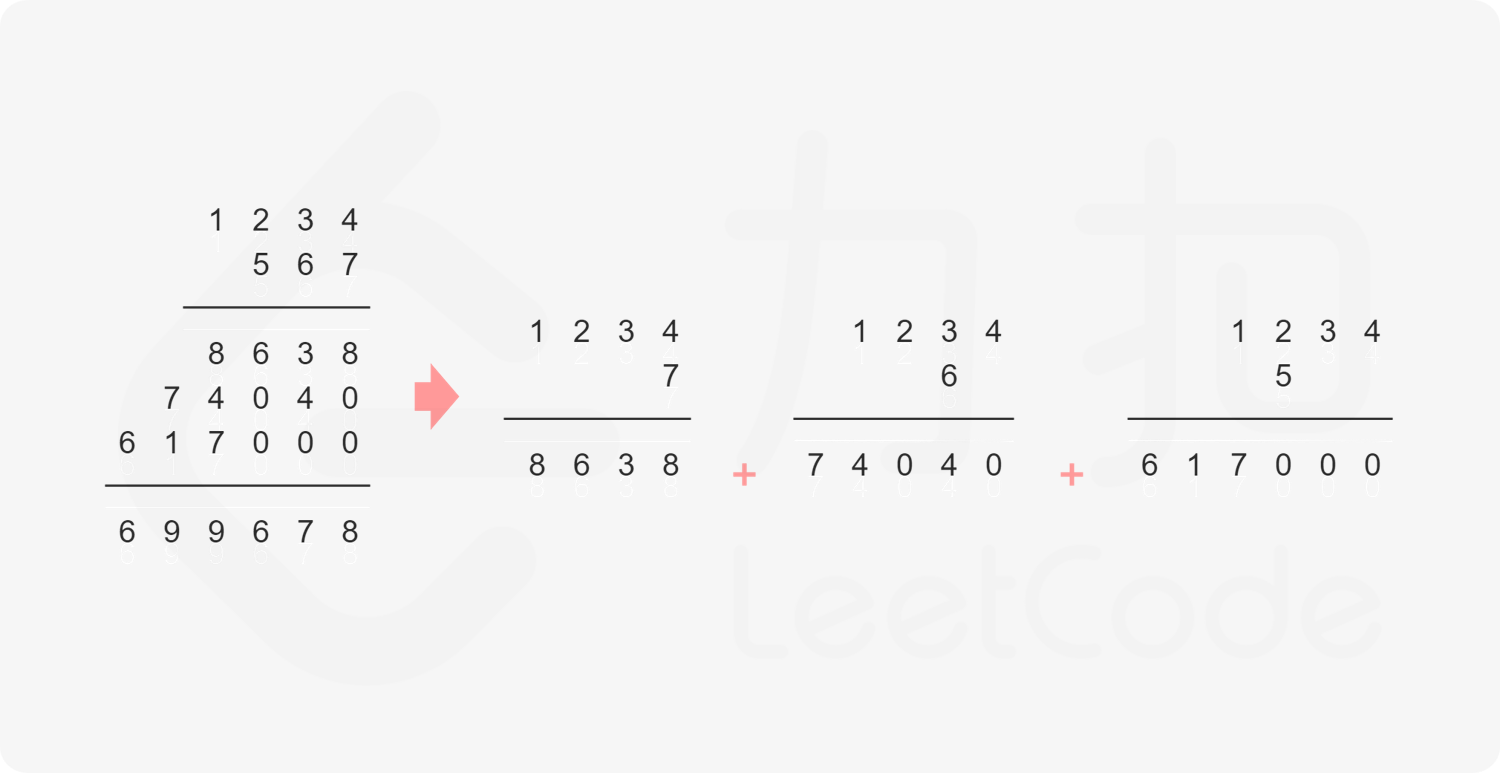

In [ ]:
#include <vector>
#include <string>
#include <iostream>

class Solution {
public:
    std::string StrAdd(std::string num1, std::string num2) {
        // 字符串加法
        std::string output = "";
        int idx1 = num1.size() - 1;
        int idx2 = num2.size() - 1;
        bool label = false;
        while (idx1 >= 0 || idx2 >= 0) {
            int val = 0;
            std::string str = "";
            if (idx1 >= 0) {
                str += num1[idx1];
                val += std::stoi(str);
                idx1 -= 1;
            }
            str = "";
            if (idx2 >= 0) {
                str += num2[idx2];
                val += std::stoi(str);
                idx2 -= 1;
            }
            if (label) {
                val += 1;
            }
            if (val >= 10) {
                label = true;
                val -= 10;
            } else {
                label = false;
            }
            output = std::to_string(val) + output;
        }
        if (label) {
            output = '1' + output;
        }
        return output;
    }
    std::string multiply(std::string num1, std::string num2) {
        if (num1 == "0" || num2 == "0") {
            return "0";
        } else if (num1 == "0") {
            return num2;
        } else if (num2 == "0") {
            return num1;
        }

        std::string output = "0";
        for (int jj = num2.size() - 1; jj >= 0; jj--) {
            if (num2[jj] == '0') {
                continue;
            }
            std::string str = "";
            int pre_digit = 0;
            for (int ii = num1.size() - 1; ii >= 0; ii--) {
                std::string str1 = "";
                std::string str2 = "";
                str1 += num1[ii];
                str2 += num2[jj];
                int val = std::stoi(str1) * std::stoi(str2) + pre_digit;
                pre_digit = val / 10;
                str = std::to_string(val % 10) + str;
            }
            if (pre_digit > 0) {
                str = std::to_string(pre_digit) + str;
            }
            
            for (int kk = 0; kk < num2.size() - 1 - jj; kk++) {
                str += '0';
            }
            output = StrAdd(output, str);
        }        
        return output;
    }
};

int main()
{  
    // 输入
    // std::string num1 = "1234";
    // std::string num2 = "567";
    std::string num1 = "3866762897776739956";
    std::string num2 = "15975363164662";

    // 构造类，并执行计算函数
    Solution s;
    std::cout << s.multiply(num1, num2) << std::endl;
}

# [1010. 总持续时间可被 60 整除的歌曲](https://leetcode.cn/problems/pairs-of-songs-with-total-durations-divisible-by-60/)
在歌曲列表中，第 i 首歌曲的持续时间为 time[i] 秒。  
返回其总持续时间（以秒为单位）可被 60 整除的歌曲对的数量。形式上，我们希望下标数字 i 和 j 满足  i < j 且有 (time[i] + time[j]) % 60 == 0。

**思路**

需要返回其总持续时间（以秒为单位）可被60整除的歌曲对的数量，因此，每首歌曲对结果的影响因素是它的持续时间除以 60 后的余数。可以用一个长度为 60 的数组 cnt，用来表示余数出现的次数。然后分情况统计歌曲对：

> 1.余数为 0 的歌曲。他们需要与余数为 0 的歌曲组成对，但不能与自己组成对。歌曲对的数量为 $cnt[0]×(cnt[0]−1)/2$。  
> 2.余数为 30 的歌曲。他们需要与余数为 30 的歌曲组成对，但不能与自己组成对。歌曲对的数量为 $cnt[30]×(cnt[30]−1)/2$。  
> 3.余数为 i,i∈[1,29] 的歌曲。他们需要与余数为 60−i 的歌曲组成对。歌曲对的数量为$\sum_{i=1}^{29} cnt[i]×cnt[60−i]$。  
> 4.余数为 i,i∈[31,59] 的歌曲。已经在上一部分组对过，不需要重复计算。  

把这几部分求和，就可以得到最后的对数。

In [ ]:
class Solution(object):
    def numPairsDivisibleBy60(self, time):
        """
        :type time: List[int]
        :rtype: int
        """
        dict_count = {}
        for num in time:
            if num % 60 not in dict_count:
                dict_count[num % 60] = 0
            dict_count[num % 60] += 1
        count = 0
        for key in dict_count.keys():
            if key == 0 or key == 30:
                count += dict_count[key] * (dict_count[key] - 1) / 2
            elif 0 < key < 30:
                if 60 - key in dict_count:
                    count += dict_count[key] * dict_count[60-key]
        return count